# iminuit Tutorial:

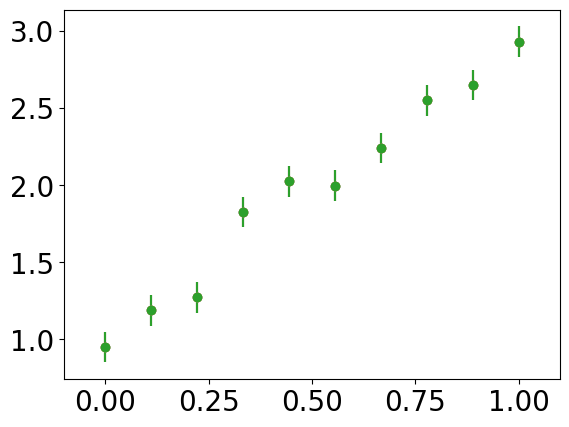

In [6]:
# let's make a line model
def line(x, a, b):
    return a + x * b

a_true = 1.0
b_true = 2.0

# let's make some data
x = np.linspace(0, 1, 10)

# precomputed random numbers from standard normal distribution
z = np.array([-0.49783783, -0.33041722, -1.71800806,  1.60229399,
                 1.36682387, -1.15424221, -0.91425267, -0.03395604,
                 -1.27611719, -0.7004073 ])

# We define some error bars too
sigma_y = 0.1 * np.ones_like(x)
y = line(x, a_true, b_true) + sigma_y * z

plt.errorbar(x, y, sigma_y, fmt="o")
plt.xlim(-0.1, 1.1);
plt.show()

* We want to estimate parameters $(a, b)$ of the lines from the data
* We need to score which is minimal when the model best agrees with data
* Sum of residual squared -> Least-squares Method
* Negated sum of log-likelihood -> Maximum-likelihood Method
* MINUIT always minimizes
* To maxmize -> Negate score function
* Use iminuit to numerically minimize score as function of model parameters

In [7]:
# least-squares score function = sum of data residuals squared
def LSQ(a, b):
    return np.sum((y - line(x, a, b)) ** 2 / sigma_y ** 2)

In [8]:
# everything in iminuit is done through the Minuit object, so we import it
from iminuit import Minuit

In [12]:
# create instance of Minuit and pass score function to minimize
# Needed to include starting values for a and b
m = Minuit(LSQ, 1, 2)

In [13]:
# set start values via keywords for a and b
m = Minuit(LSQ, a=5, b=5)

In [14]:
# set step size with error_<name>=... keyword
m = Minuit(LSQ, a=5, b=5, error_a=0.1, error_b=0.1)

RuntimeError: error_a is not one of the parameters [a b]

## Basics:

### Quick Start:

* iminuit combines a local minimizer (MIGRAD) and two error calculators (HESSE and MINOS)
* Prove analytical multivariable function and an intial guess of parameters values
* iminuit then finds a local min of the function from the startin guess
* Can also compute uncertainty estimates for model parameters
* iminuit was designed to solve stats problems where uncert estimates are an essential part of the results

In [1]:
# basic setup of the notebook
%config InlineBackend.figure_formats = ['svg']
from matplotlib import pyplot as plt
import numpy as np

# everything in iminuit is done through the Minuit object, so we import it
from iminuit import Minuit

# we also need a cost function to fit and import the LeastSquares function
from iminuit.cost import LeastSquares

# display iminuit version
import iminuit

print("iminuit version:", iminuit.__version__)

iminuit version: 2.31.1


In [2]:
# our line model, unicode parameter names are supported :)
def line(x, α, β):
    return α + x * β


# generate random toy data with random offsets in y
rng = np.random.default_rng(1)
data_x = np.linspace(0, 1, 10)
data_yerr = 0.1  # could also be an array
data_y = rng.normal(line(data_x, 1, 2), data_yerr)

* To recover $\alpha$ and $\beta$, we need to minimize a suitable cost function
* The cost function must be twice differentiable and have a minimum at the optimal parameters
* We use the method of least-squares here, whose cost function computes the sum of squarred residuals between the model and the data
* iminuit will find the minimum of that function- thus finding the optimal parameters for the fit

* iminuit allows us to generate a least-squares cost function (later we will show how to write one)
* The plots and information get automatically rendered in a Jupyter Notebook

In [6]:
least_squares = LeastSquares(data_x, data_y, data_yerr, line)

m = Minuit(least_squares, α=0, β=0)  # starting values for α and β

m.migrad()  # finds minimum of least_squares function
m.hesse()  # accurately computes uncertainties

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.959 (χ²/ndof = 0.5)      │              Nfcn = 46               │
│ EDM = 3.65e-21 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ α    │   1.02    │   0.06    │            │            │         │         │       │
│ 1 │ β    │    2.0    │    0.1    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────┐
│   │       α       β │
├───┼─────────────────┤
│ α │ 0.00345 -0.0049 │
│ β │ -0.0049 0.00982 │
└───┴─────────────────┘

* The plot can be made nicer by hand

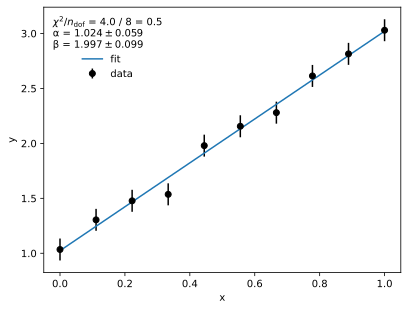

In [5]:
# draw data and fitted line
plt.errorbar(data_x, data_y, data_yerr, fmt="ok", label="data")
plt.plot(data_x, line(data_x, *m.values), label="fit")

# display legend with some fit info
fit_info = [
    f"$\\chi^2$/$n_\\mathrm{{dof}}$ = {m.fval:.1f} / {m.ndof:.0f} = {m.fmin.reduced_chi2:.1f}",
]
for p, v, e in zip(m.parameters, m.values, m.errors):
    fit_info.append(f"{p} = ${v:.3f} \\pm {e:.3f}$")

plt.legend(title="\n".join(fit_info), frameon=False)
plt.xlabel("x")
plt.ylabel("y");

### Intialize Minuit Object

* To minimize a function, one has to create an instance of the minuit class
* Then you must pass the function and a starting value for each parameter
* This does not start minimization, that comes a bit later

In [8]:
# We must imclude both parameters:
m = Minuit(least_squares, α=0, β=0)

### Initial Parameter Values

* The main algorithm MIGRAD is a local minimizer
* Searches for local mins doing a mix of Newton steps and gradient-descents from some starting point
* For functions with muliple minima, the minimum found will depend on the starting point
* iminuit will always converge faster the closer you are to a local minimum

In [11]:
# You can set the starting point using the parmeter names as keywords: <name> = <value>
Minuit(least_squares, α=5, β=5)  # pass starting values for α and β

,Name,Value,Hesse Error,Minos Error-,Minos Error+,Limit-,Limit+,Fixed
0,α,5.00,0.05,,,,,
1,β,5.00,0.05,,,,,


In [12]:
# Starting values can also be passed as positional arguments:
Minuit(least_squares, 5, 5)  # another way of passing starting values for α and β

,Name,Value,Hesse Error,Minos Error-,Minos Error+,Limit-,Limit+,Fixed
0,α,5.00,0.05,,,,,
1,β,5.00,0.05,,,,,


* iminuit can also be used with functions that accept numpy arrays
* Pros: Easy to change number of fitted params, sometimes simpler function body, technically more efficient
* Cons: iminuit cannot figure out names for each parameter

In [13]:
# We demonstrate this by using a version of the line model that accepts parameters as a numpy array
def line_np(x, par):
    return np.polyval(par, x)  # for len(par) == 2, this is a line

In [15]:
from iminuit import Minuit

def parabola(a, b):
    return (a - 1)**2 + (b + 2)**2 + 10

m = Minuit(parabola, a=0, b=0)  # initial guesses
m.migrad()

print("Minimum found at:")
print(f"a = {m.values['a']} ± {m.errors['a']}")
print(f"b = {m.values['b']} ± {m.errors['b']}")


Minimum found at:
a = 0.9999999999037257 ± 0.9999999999518838
b = -1.9999999996349853 ± 0.9999999999087456


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit

# Data
x = np.linspace(0, 10, 20)
y = 3 * x + 2 + np.random.normal(0, 1, size=x.size)
yerr = np.ones_like(y)

# Chi-square function
def chi2(m, c):
    model = m * x + c
    return np.sum(((y - model) / yerr)**2)

# Minimize
m = Minuit(chi2, m=1, c=0)
m.migrad()

# Results
print(m.values)
print(m.errors)


<ValueView m=2.9873909071975744 c=2.084250842614286>
<ErrorView m=0.07367883984721027 c=0.4309458039611195>


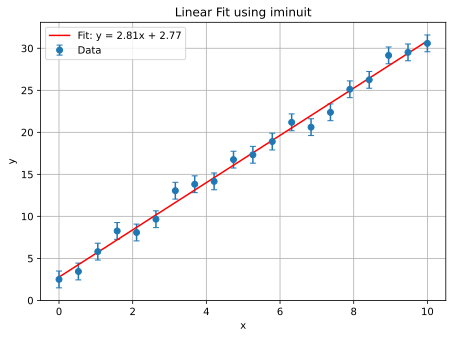

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit

# Generate synthetic linear data
np.random.seed(42)
x = np.linspace(0, 10, 20)
true_m = 3.0
true_c = 2.0
y = true_m * x + true_c + np.random.normal(0, 1.0, size=x.size)
yerr = np.ones_like(y)

# Define chi-squared function
def chi2(m, c):
    model = m * x + c
    return np.sum(((y - model) / yerr)**2)

# Fit using iminuit
m = Minuit(chi2, m=1.0, c=0.0)
m.migrad()

# Best-fit parameters
best_m = m.values['m']
best_c = m.values['c']

# Plotting
plt.errorbar(x, y, yerr=yerr, fmt='o', label='Data', capsize=3)
plt.plot(x, best_m * x + best_c, 'r-', label=f'Fit: y = {best_m:.2f}x + {best_c:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Fit using iminuit')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


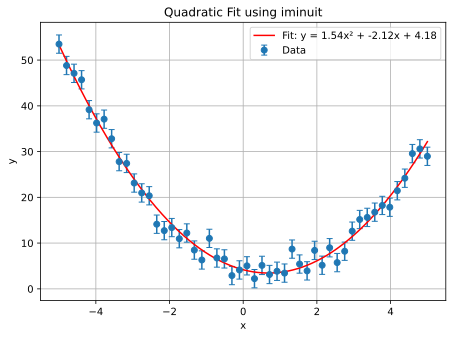

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit

# Generate synthetic quadratic data
np.random.seed(42)
x = np.linspace(-5, 5, 50)
true_a = 1.5
true_b = -2.0
true_c = 5.0
y_true = true_a * x**2 + true_b * x + true_c
noise = np.random.normal(0, 2.0, size=x.size)
y = y_true + noise
yerr = np.full_like(y, 2.0)  # constant error bars

# Define chi-squared function for parabola
def chi2(a, b, c):
    model = a * x**2 + b * x + c
    return np.sum(((y - model) / yerr)**2)

# Fit using iminuit
m = Minuit(chi2, a=1.0, b=0.0, c=0.0)
m.migrad()

# Extract best-fit parameters
best_a = m.values['a']
best_b = m.values['b']
best_c = m.values['c']

# Plotting
plt.errorbar(x, y, yerr=yerr, fmt='o', label='Data', capsize=3)
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = best_a * x_fit**2 + best_b * x_fit + best_c
plt.plot(x_fit, y_fit, 'r-', label=f'Fit: y = {best_a:.2f}x² + {best_b:.2f}x + {best_c:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Quadratic Fit using iminuit')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


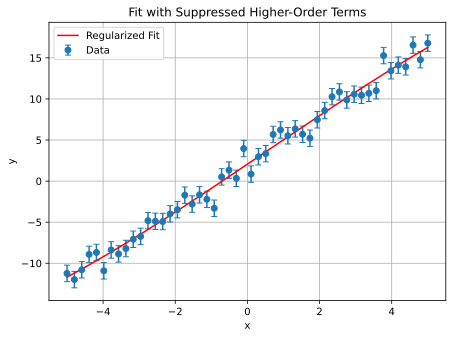

TypeError: __getitem__(): incompatible function arguments. The following argument types are supported:
    1. (self: iminuit._core.MnUserParameterState, arg0: int) -> iminuit._core.MinuitParameter

Invoked with: <iminuit._core.MnUserParameterState object at 0x000002B0B156D030>, 2.060871477169936

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit

# Generate synthetic data (linear)
np.random.seed(0)
x = np.linspace(-5, 5, 50)
y = 3 * x + 2 + np.random.normal(0, 1, size=x.size)
yerr = np.ones_like(y)

# Define objective function (chi2 + regularization on higher-order terms)
def loss(a0, a1, a2, a3, lam=10.0):
    model = a0 + a1 * x + a2 * x**2 + a3 * x**3
    chi2 = np.sum(((y - model) / yerr)**2)
    penalty = lam * (a2**2 + a3**2)  # L2 penalty on higher-order terms
    return chi2 + penalty

# Wrap loss function so iminuit doesn't see 'lam' as a fit parameter
def loss_fixed(a0, a1, a2, a3):
    return loss(a0, a1, a2, a3, lam=10.0)

# Fit using iminuit
m = Minuit(loss_fixed, a0=0, a1=0, a2=0, a3=0)
m.migrad()

# Extract fit values
best = m.values

# Plot
x_fit = np.linspace(-5, 5, 500)
y_fit = best['a0'] + best['a1']*x_fit + best['a2']*x_fit**2 + best['a3']*x_fit**3

plt.errorbar(x, y, yerr=yerr, fmt='o', label='Data', capsize=3)
plt.plot(x_fit, y_fit, 'r-', label='Regularized Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Fit with Suppressed Higher-Order Terms')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print coefficients
for name in best:
    print(f"{name} = {best[name]:.4f}")



Fit Results:
a   =   1.5611 ± 0.0459
b   =  -2.2038 ± 0.1223
c   =   4.0796 ± 0.5482

Function minimum value (chi2): 18.94438959503175
Degrees of freedom: 27
Parameter correlation matrix:
 ┌───┬────────────────┐
│   │    a    b    c │
├───┼────────────────┤
│ a │    1    0 -0.7 │
│ b │    0    1    0 │
│ c │ -0.7    0    1 │
└───┴────────────────┘


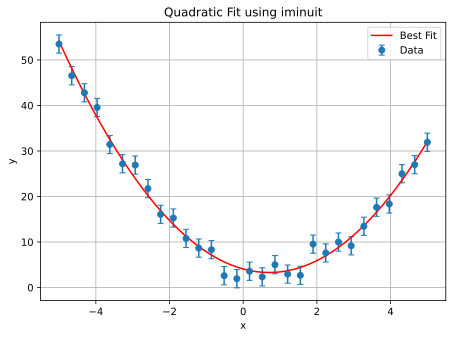

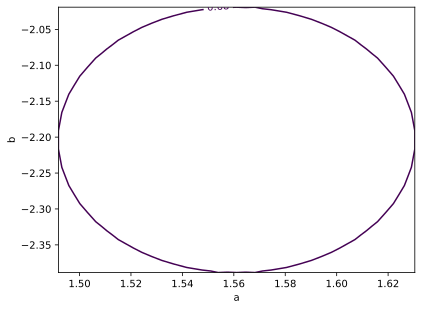

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.util import describe

# -------------------------------
# 1. Generate synthetic data
# -------------------------------
np.random.seed(42)
x = np.linspace(-5, 5, 30)
# True model: y = 1.5x^2 - 2x + 5
y_true = 1.5 * x**2 - 2 * x + 5
noise = np.random.normal(0, 2.0, size=x.size)
y = y_true + noise
yerr = np.full_like(y, 2.0)  # Constant uncertainty

# -------------------------------
# 2. Define a chi-square function
# -------------------------------
def chi2(a, b, c):
    """Chi-squared function for a quadratic model: a*x^2 + b*x + c"""
    model = a * x**2 + b * x + c
    return np.sum(((y - model) / yerr)**2)

# -------------------------------
# 3. Initialize Minuit
# -------------------------------
# iminuit requires named arguments, so provide initial guesses with keywords
m = Minuit(chi2, a=1.0, b=0.0, c=0.0)

# Optional: Set limits or fix parameters
m.limits["a"] = (0, None)      # Constrain 'a' to be positive
# m.fixed["c"] = True          # Uncomment to fix 'c'

# -------------------------------
# 4. Run minimization
# -------------------------------
m.migrad()     # Main minimization algorithm
m.hesse()      # Estimate symmetric errors
m.minos()      # Optional: Estimate asymmetric errors (slower)

# -------------------------------
# 5. Print fit results
# -------------------------------
print("\nFit Results:")
for name in m.parameters:
    print(f"{name:3} = {m.values[name]:8.4f} ± {m.errors[name]:6.4f}")

# Access full results
print("\nFunction minimum value (chi2):", m.fval)
print("Degrees of freedom:", len(x) - m.nfit)
print("Parameter correlation matrix:\n", m.covariance.correlation())

# -------------------------------
# 6. Plot results
# -------------------------------
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = m.values["a"] * x_fit**2 + m.values["b"] * x_fit + m.values["c"]

plt.errorbar(x, y, yerr=yerr, fmt='o', label='Data', capsize=3)
plt.plot(x_fit, y_fit, 'r-', label='Best Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Quadratic Fit using iminuit')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------
# 7. Optional: Visualizations
# -------------------------------
# Contour plot for parameter pairs
m.draw_mncontour("a", "b")  # Requires matplotlib


In [20]:
# Issue: We need to minimize up to n_max